In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [11]:
RAW_DIR = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_fitness_inference/raw_counts/FLU")

P0_PATH = RAW_DIR / "counts_P0.tsv"

OUT_DIR = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/GRC/log_enrichment/")
OUT_DIR.mkdir(exist_ok=True)

CONDITIONS = ["C", "Q", "H", "F"]
REPS = [1, 2, 3]

MIN_P0_COUNT = 50
PSEUDOCOUNT = 0.5

In [12]:
def read_count_file(path, count_col_name):
    df = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=["BC", count_col_name]
    )
    
    df[count_col_name] = pd.to_numeric(
        df[count_col_name],
        errors="coerce"
    ).fillna(0)
    
    return df

In [13]:
p0_df = read_count_file(
    P0_PATH,
    count_col_name="P0"
)

p0_df = p0_df[p0_df["P0"] >= MIN_P0_COUNT].copy()

print("P0 file:", P0_PATH)
print("Number of P0 barcodes after filtering:", p0_df["BC"].nunique())
print("Minimum retained P0 count:", p0_df["P0"].min())

p0_df.head()

P0 file: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_fitness_inference/raw_counts/FLU/counts_P0.tsv
Number of P0 barcodes after filtering: 83099
Minimum retained P0 count: 50.0


,BC,P0
0,AAAAAAAACAAACGGAATTATAGCATGTGGAA,436.0
1,AAAAAAAACAAACGGATCACTATTCGTAAAGA,2058.0
2,AAAAAAAACTTGGAAAATTACTATTAAACAAG,1715.0
3,AAAAAAAACTTGGAAATGTCAAGGCTAACGAG,128.0
4,AAAAAAAAGTGATGGAACGAAGTCAGTTCTCA,196.0


In [14]:
all_log_enrichment = []

for cond in CONDITIONS:
    for rep in REPS:
        
        p1_path = RAW_DIR / f"counts_{cond}_P1_{rep}.tsv"
        
        if not p1_path.exists():
            print(f"Missing file, skipping: {p1_path}")
            continue
        
        p1_df = read_count_file(
            p1_path,
            count_col_name="P1"
        )
        
        # Keep only lineages present in both filtered P0 and this P1 file
        merged = p0_df.merge(
            p1_df,
            on="BC",
            how="inner"
        )
        
        merged["condition"] = cond
        merged["rep"] = rep
        
        merged["log_enrichment"] = np.log(
            (merged["P1"] + PSEUDOCOUNT) /
            (merged["P0"] + PSEUDOCOUNT)
        )
        
        all_log_enrichment.append(
            merged[
                [
                    "BC",
                    "condition",
                    "rep",
                    "P0",
                    "P1",
                    "log_enrichment"
                ]
            ]
        )

log_enrichment_long = pd.concat(
    all_log_enrichment,
    ignore_index=True
)

out_long = OUT_DIR / "fluconazole_log_P1_over_P0_common_P0_P1_long.tsv"
log_enrichment_long.to_csv(out_long, sep="\t", index=False)

print(f"Saved: {out_long}")
print(log_enrichment_long.shape)

log_enrichment_long.head()

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/GRC/log_enrichment/fluconazole_log_P1_over_P0_common_P0_P1_long.tsv
(867787, 6)


,BC,condition,rep,P0,P1,log_enrichment
0,AAAAAAAACAAACGGAATTATAGCATGTGGAA,C,1,436.0,132.0,-1.192206
1,AAAAAAAACAAACGGATCACTATTCGTAAAGA,C,1,2058.0,1188.0,-0.549286
2,AAAAAAAACTTGGAAAATTACTATTAAACAAG,C,1,1715.0,805.0,-0.755997
3,AAAAAAAACTTGGAAATGTCAAGGCTAACGAG,C,1,128.0,70.0,-0.600316
4,AAAAAAAAGTGATGGAACGAAGTCAGTTCTCA,C,1,196.0,69.0,-1.039336


In [15]:
retention_summary = (
    log_enrichment_long
    .groupby(["condition", "rep"])
    .agg(
        n_common_P0_P1=("BC", "nunique"),
        median_P0=("P0", "median"),
        median_P1=("P1", "median"),
        total_P1_reads=("P1", "sum")
    )
    .reset_index()
)

retention_out = OUT_DIR / "fluconazole_common_P0_P1_retention_summary.tsv"
retention_summary.to_csv(retention_out, sep="\t", index=False)

print(f"Saved: {retention_out}")
retention_summary

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/GRC/log_enrichment/fluconazole_common_P0_P1_retention_summary.tsv


,condition,rep,n_common_P0_P1,median_P0,median_P1,total_P1_reads
0,C,1,79990,695.5,298.0,58518182.0
1,C,2,80056,695.0,316.0,63342891.0
2,C,3,78263,721.0,242.0,46539276.0
3,F,1,70705,839.0,118.0,41524401.0
4,F,2,73531,793.0,138.0,49496569.0
5,F,3,70467,840.0,120.0,48513762.0
6,H,1,75257,766.0,167.0,35091713.0
7,H,2,77929,726.0,220.0,52283984.0
8,H,3,78403,719.0,230.0,50098057.0
9,Q,1,80660,685.0,349.0,74567166.0


In [16]:
log_enrichment_wide = log_enrichment_long.pivot_table(
    index=["BC", "condition"],
    columns="rep",
    values="log_enrichment"
).reset_index()

log_enrichment_wide = log_enrichment_wide.rename(
    columns={
        1: "log_enrichment_rep1",
        2: "log_enrichment_rep2",
        3: "log_enrichment_rep3"
    }
)

out_wide = OUT_DIR / "fluconazole_log_P1_over_P0_common_P0_P1_wide.tsv"
log_enrichment_wide.to_csv(out_wide, sep="\t", index=False)

print(f"Saved: {out_wide}")
print(log_enrichment_wide.shape)

log_enrichment_wide.head()

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/GRC/log_enrichment/fluconazole_log_P1_over_P0_common_P0_P1_wide.tsv
(323380, 5)


rep,BC,condition,log_enrichment_rep1,log_enrichment_rep2,log_enrichment_rep3
0,AAAAAAAACAAACGGAATTATAGCATGTGGAA,C,-1.192206,-0.803228,-1.642037
1,AAAAAAAACAAACGGAATTATAGCATGTGGAA,F,-1.364764,-0.928391,-0.763122
2,AAAAAAAACAAACGGAATTATAGCATGTGGAA,H,-1.584550,-0.839690,-1.091763
3,AAAAAAAACAAACGGAATTATAGCATGTGGAA,Q,-0.687436,NaN,-0.583671
4,AAAAAAAACAAACGGATCACTATTCGTAAAGA,C,-0.549286,-0.698749,-0.878047


In [17]:
def plot_rep_correlation(df, condition, rep_x, rep_y, ax):
    
    xcol = f"log_enrichment_rep{rep_x}"
    ycol = f"log_enrichment_rep{rep_y}"
    
    plot_df = df[
        df["condition"] == condition
    ][[xcol, ycol]].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()
    
    x = plot_df[xcol].values
    y = plot_df[ycol].values
    
    r, _ = pearsonr(x, y)
    r2 = r ** 2
    
    ax.scatter(
        x,
        y,
        s=5,
        alpha=0.08,
        color="black",
        edgecolors="none"
    )
    
    ax.text(
        0.07,
        0.93,
        rf"$R^2$ = {r2:.2f}",
        transform=ax.transAxes,
        fontsize=13,
        va="top"
    )
    
    ax.set_title(f"{condition}", fontsize=13)
    ax.set_xlabel(f"Fitness rep. {rep_x}")
    ax.set_ylabel(f"Fitness rep. {rep_y}")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    return r2, len(plot_df)

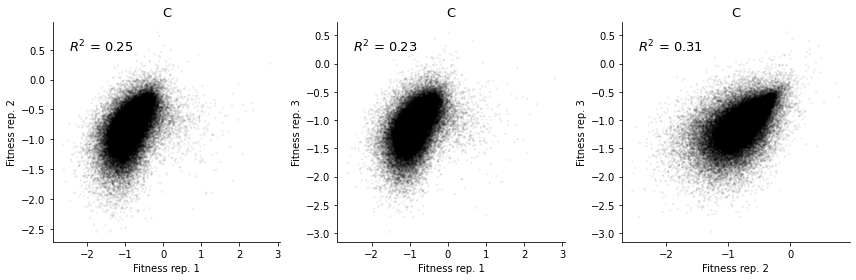

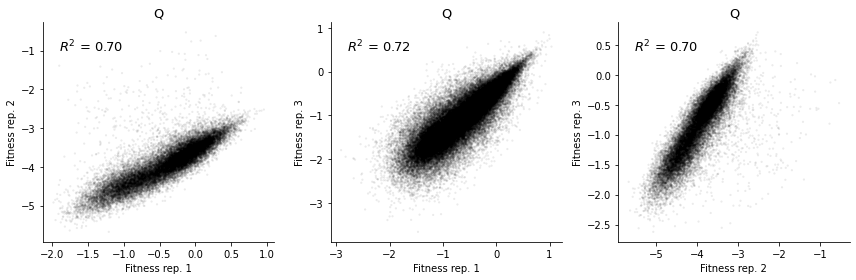

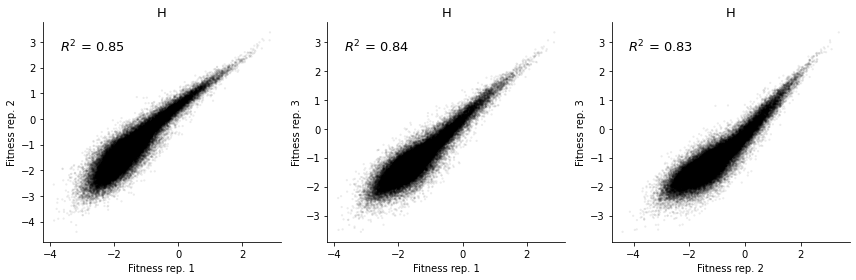

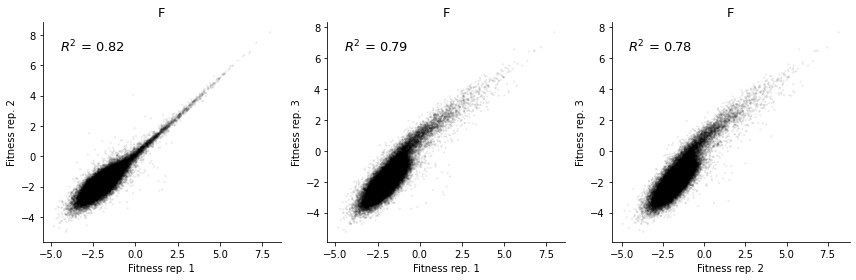

,condition,rep_x,rep_y,R2,n_barcodes_common_between_reps
0,C,1,2,0.247824,78212
1,C,1,3,0.233035,76860
2,C,2,3,0.308209,76889
3,Q,1,2,0.695820,24739
4,Q,1,3,0.715743,76892
5,Q,2,3,0.704882,24735
6,H,1,2,0.849585,73487
7,H,1,3,0.844816,73709
8,H,2,3,0.829778,75689
9,F,1,2,0.823551,67408


In [18]:
rep_pairs = [(1, 2), (1, 3), (2, 3)]

summary_rows = []

for cond in CONDITIONS:
    
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12, 4)
    )
    
    for ax, (rep_x, rep_y) in zip(axes, rep_pairs):
        
        r2, n = plot_rep_correlation(
            df=log_enrichment_wide,
            condition=cond,
            rep_x=rep_x,
            rep_y=rep_y,
            ax=ax
        )
        
        summary_rows.append({
            "condition": cond,
            "rep_x": rep_x,
            "rep_y": rep_y,
            "R2": r2,
            "n_barcodes_common_between_reps": n
        })
    
    # fig.suptitle(
    #     f"Fluconazole {cond}: log(P1/P0), common P0-P1 lineages only",
    #     fontsize=14
    # )
    
    plt.tight_layout()
    
    out_png = OUT_DIR / f"scatter_log_P1_over_P0_common_P0_P1_{cond}.png"
    out_pdf = OUT_DIR / f"scatter_log_P1_over_P0_common_P0_P1_{cond}.pdf"
    
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    # plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
    
    plt.show()

r2_summary = pd.DataFrame(summary_rows)
r2_summary